In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer

In [2]:
data = pd.read_excel('data/data_ford_price.xlsx')

# QUANTILE TRANSFORMER

Этот метод трансформации признаков преобразует распределение переменной в нормальное или равномерное распределение и масштабирует его соответствующим образом.

Квантильное преобразование сопоставляет распределение вероятностей переменной с другим распределением вероятностей с использованием квантильной функции.

Квантильная функция, также называемая функцией процентной точки (PPF), является обратной функцией кумулятивного распределения вероятностей (CDF).

CDF — это функция, которая возвращает вероятность значения, равного или меньше заданного значения.

PPF является инверсией этой функции и возвращает значение с заданной вероятностью или ниже неё.

Поскольку этот метод изменяет само распределение переменных, из-за этого скейлера линейные отношения между переменными могут быть разрушены. Таким образом, лучше всего использовать его для нелинейных данных.

Применим данное преобразование к признаку year. Для начала посмотрим на его распределение.

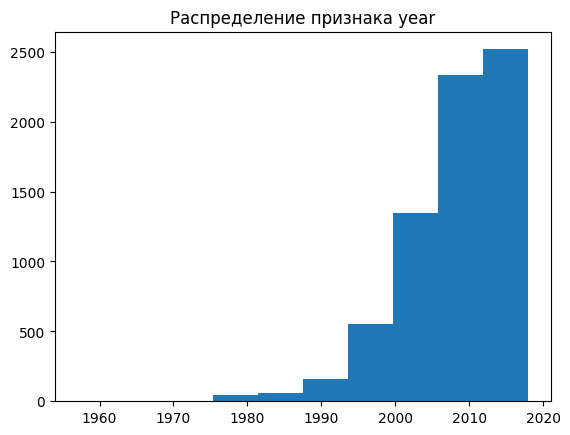

In [3]:
plt.hist(data.year)
plt.title('Распределение признака year');

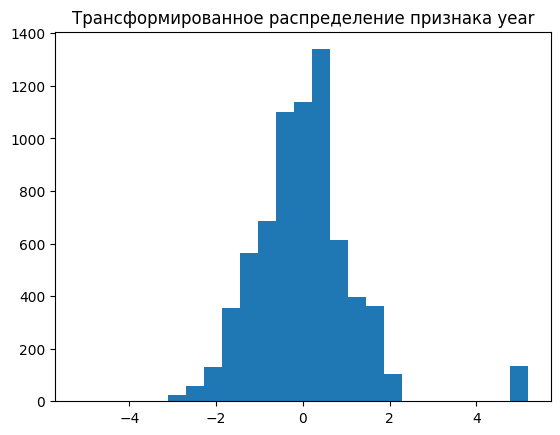

In [4]:
# Данный трансформер принимает на вход 2D-массив, поэтому нам надо изменить формат данных (поскольку мы подаём на вход только один столбец)
data_for_transform = data['year'].values.reshape((len(data),1))

quantile = QuantileTransformer(output_distribution='normal')
data_transformed = quantile.fit_transform(data_for_transform)

plt.hist(data_transformed, bins=25)
plt.title('Трансформированное распределение признака year')
plt.show()

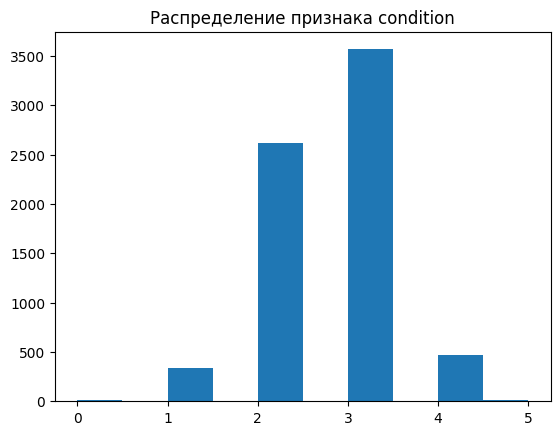

In [5]:
plt.hist(data.condition)
plt.title('Распределение признака condition');

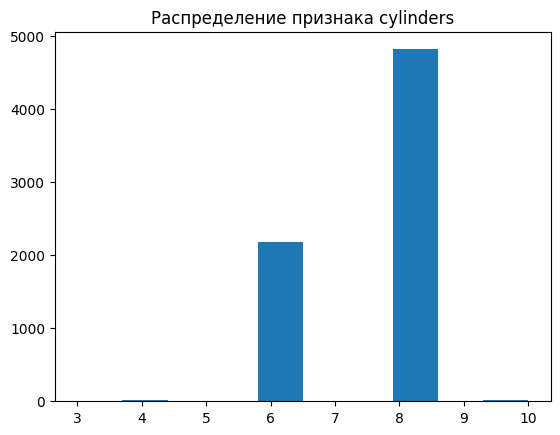

In [6]:
plt.hist(data.cylinders)
plt.title('Распределение признака cylinders');

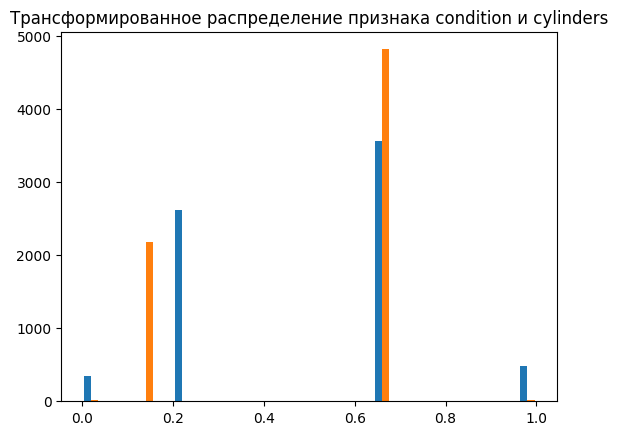

In [8]:
data_for_transform = data[['condition', 'cylinders']]
quantile = QuantileTransformer(output_distribution='uniform')
data_transformed = quantile.fit_transform(data_for_transform)
np.round(data_transformed[0][0],2)

plt.hist(data_transformed, bins=25)
plt.title('Трансформированное распределение признака condition и cylinders')
plt.show()

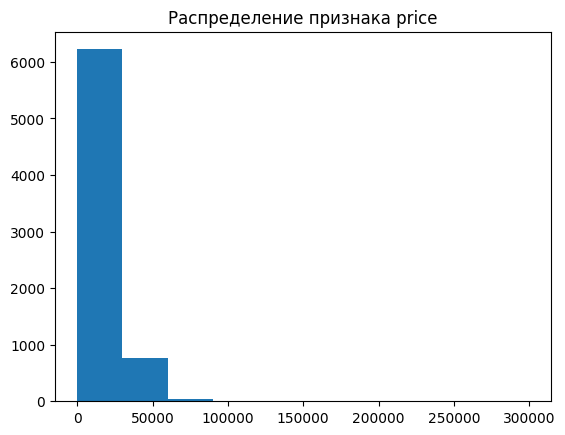

In [9]:
plt.hist(data.price)
plt.title('Распределение признака price');

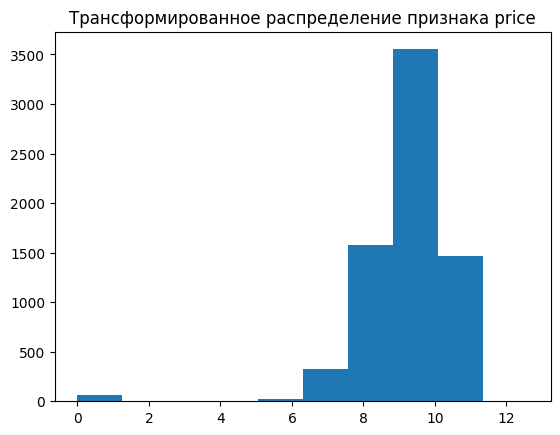

In [10]:
log_price = np.log(data['price'])

plt.hist(log_price)
plt.title('Трансформированное распределение признака price')
plt.show()

сравним значения исходного и трансформированного признака.

In [11]:
price_data = pd.concat([data['price'], log_price.rename('transformed_price')], axis = 1)

price_data.describe()

,price,transformed_price
count,7017.000000,7017.000000
mean,15121.549523,9.204510
std,11765.423119,1.275868
min,1.000000,0.000000
25%,5995.000000,8.698681
50%,12750.000000,9.453287
75%,21995.000000,9.998570
max,299500.000000,12.609870


Теперь вместо экстремального разброса значений в 1 и 299500 мы получили 0 и 12.6. Таким образом, логарифмическое преобразование сыграло роль в уменьшении влияния слишком низких и слишком высоких значений.

Стоит учесть, что, если наши данные имеют отрицательные значения или значения в диапазоне от 0 до 1, мы не можем применить логарифмическое преобразование напрямую, поскольку логарифм отрицательных чисел и 0 не определён, то есть мы получим ошибки или значения NaN в наших данных. В таких случаях мы можем добавить число к этим значениям, чтобы все они были больше 1.

In [12]:
price_data['transformed_price'].iloc[price_data.shape[0] - 1]

np.float64(9.798127036878302)

# POWER TRANSFORMER SCALER

Как и другие скейлеры, с которыми вы уже познакомились, Power Transformer также изменяет распределение переменной, то есть делает его более гауссовым (нормальным).

Однако чтобы использовать все изученные раннее методы трансформации и скейлинга, необходимо сначала понять исходное распределение признака, а затем уже делать выбор. Power Transformer фактически автоматизирует принятие этого решения, вводя параметр, называемый lambda. Он принимает решение об обобщённом степенном преобразовании, находя наилучшее значение lambda и используя один из следующих параметрических методов:

Преобразование Бокса-Кокса, которое работает для положительных значений признака.
Преобразование Йео-Джонсона, которое учитывает при расчётах нулевые и отрицательные значения обрабатываемых переменных.
В нашем случае мы будем использовать преобразование Бокса-Кокса, так как все значения положительны.

In [6]:
# box_cox = PowerTransformer(method = 'box-cox')
#
# data_box_cox = box_cox.fit_transform(data[['price', 'year']].values)
# data_box_cox = pd.DataFrame(data_box_cox, columns = ['transformed_price', 'transformed_year'])

import pandas as pd
from sklearn.preprocessing import PowerTransformer

# Предположим, что data — это DataFrame с колонками 'price' и 'year'
# Проверим наличие и корректность данных
if 'price' not in data.columns or 'year' not in data.columns:
    raise ValueError("В DataFrame отсутствуют колонки 'price' и 'year'")

# Проверим, есть ли отрицательные значения или нули
if (data[['price', 'year']] <= 0).any().any():
    raise ValueError("Для применения Box-Cox все значения должны быть положительными")

# Преобразование с помощью PowerTransformer
box_cox = PowerTransformer(method='box-cox')

# Создадим копию ДФ для проеобразования boxcox scipy
test_data_year = data.copy()

from scipy.stats import boxcox

data_box_cox_price = box_cox.fit_transform(data[['price']].values)

data_box_cox_year,  = boxcox(test_data_year['year'])

# Создадим DataFrame с преобразованными данными
data_box_cox_price = pd.DataFrame(data_box_cox_price, columns=['transformed_price'])
data_box_cox_year = pd.DataFrame(data_box_cox_year, columns=['transformed_year'])

data_box_cox = pd.concat([data_box_cox_price, data_box_cox_year], axis=1)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_morestats.py:1153: UserWarning: The optimal lambda is 123.77781881071438, but the returned lambda is the constrained optimum to ensure that the maximum or the minimum of the transformed data does not overflow in <class 'numpy.float64'>.
  lmax = boxcox_normmax(x, method='mle', optimizer=optimizer)


ValueError: too many values to unpack (expected 1)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7065: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7066: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

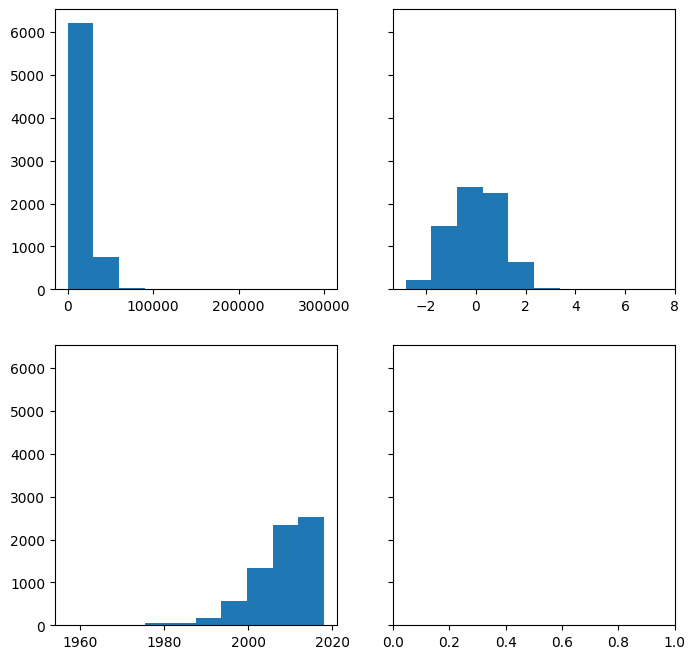

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharey=True)
axs[0][0].hist(data['price'])
axs[1][0].hist(data['year'])
axs[0][1].hist(data_box_cox['transformed_price'])
axs[1][1].hist(data_box_cox['transformed_year'])

axs[0][0].set(title='price')
axs[0][1].set(title='box cox price')

axs[1][0].set(title='year')
axs[1][1].set(title='box cox year')

fig.suptitle('Сравнение распределений до трансформации и после')

plt.show()